# How to load modes from a FELiCS run and save them

Before you start, you should install all necessary FELiCS packages, and install FELiCS as a package itself. The [installation guide](https://felics-d43476.gitlab.io/installation_guide.html) explains those steps in detail. After installing FELiCS you can start writing your first FELiCS script.

--- 
## Description

This tutorial describes how to load back modes from a previous stability analysis in FELiCS for post-processing, and how
to easily save them back to the drive. We use the 2D cylinder wake example for illustration.

---
## Loading FELiCS results

We start by loading the pre-computed stability results as FELiCS *mode objects*.

This allows us to:
- Inspect the modes directly within FELiCS (instead of only visualizing them in ParaView),
- Evaluate expressions involving the mode shapes, such as the structural sensitivity.

### Reconstructing the FEM context

The saved mode files contain the degrees of freedom of the eigenvectors.  
To interpret them as finite-element fields, we must reconstruct the same mesh and function spaces that were used during the stability computation.

🔧 **Load the FELiCS modules**  
We begin by loading the necessary FELiCS modules, as well as the `ufl` package, which allows us to define and evaluate finite-element expressions.

In [1]:
# Set the environment variable OMP_NUM_THREADS
%env OMP_NUM_THREADS=1

# Load FELiCS modules
from    FELiCS.Parameters.Config            import  Config
from    FELiCS.Misc.logging                 import  Logger
from    FELiCS.IO.Reader                    import  Reader
from    FELiCS.Fields.Field                 import  Field
from    FELiCS.IO.Writer                    import  Writer
from    FELiCS.SpaceDisc.FEMSpaces          import  FEMSpaces
from    FELiCS.Fields.ModeCollection        import  ModeCollection
from    FELiCS.Misc.tensorUtils             import  Tensor, i_dot, i_conj
from    FELiCS.Equation.UflDecorator        import  UflDecorator
from    FELiCS.Fields.MeanFlowClass         import  MeanFlowClass

env: OMP_NUM_THREADS=1
(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


fatal: not a git repository: '/home/demange/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'


🔧 **Reconstruct the FELiCS objects**  

We now rebuild the FELiCS objects needed for the sensitivity analysis. These are created using the same **configuration file** that was used for the modal stability analysis.

*This ensures that the mesh, finite-element spaces, and physical parameters are identical to those used when computing the eigenmodes.*

In [2]:
# Get the logger for nice printout messages
logger      = Logger(True, False, "felics")
logger      = Logger.get_logger("felics")

# Load the configuration file that was used for the stability analysis. 
param       = Config()
param.import_from_file("Input/config.json")

# We get the mesh object
mesh        = param.get_mesh()

# The FEM spaces used for the stability analysis
FEMSpaces   = FEMSpaces(param, mesh)

Debug    | logging.py             | _setup_logger              (line 245 ) : Logger initialized successfully
Debug    | Config.py              | __init__                   (line 68  ) : Initializing config class with defaults.
Info     | Config.py              | import_from_file           (line 245 ) : Loading configuration from Input/config.json
Warning  | Config.py              | import_from_file           (line 264 ) : Field "MolViscPerturbModel" missing from file, setting default: {'type': 'Constant', 'Constants': {'Viscosity': 1.0}}
Warning  | Config.py              | import_from_file           (line 264 ) : Field "PrandtlNumber" missing from file, setting default: 0.72
Warning  | Config.py              | import_from_file           (line 264 ) : Field "ForcingNorm" missing from file, setting default: TKE
Warning  | Config.py              | import_from_file           (line 264 ) : Field "ResponseNorm" missing from file, setting default: TKE
Debug    | Config.py              | impor

📥 **Initialize the Reader**

We now create a `reader` object to load the saved mode data into FELiCS.

In [3]:
reader = Reader(
    sourceDir           = "Input",
    needInterpolation   = False,
)

---
### Loading FELiCS modes

We first create an empty FELiCS `ModeCollection`. This object is used to manage groups of modes (eigenvalues and corresponding mode shapes), facilitates filtering, and provides utility functions (descriptions, sorting, exporting, etc.).

By providing the `reader` to this collection, we can load all FELiCS modes saved in the 'results/' directory.

In [4]:
# Create empty mode collection to import into
importSolution  = ModeCollection(
    FEMSpaces.VMixed,
    mesh
)

# Load all the modes from the reader source directory into the mode collection
importSolution.import_data(
    reader,
)

Info     | ModeCollection.py      | import_data                (line 1111) : 20 modes to import into mode collection.
Info     | ModeCollection.py      | import_data                (line 1113) : Importing mode 1/20 from file "Mode_Modal_Direct_Omega_0.751-0.099j.h5".
Debug    | Reader.py              | _update_calc_mesh          (line 459 ) : New calculation mesh / FEM space type, updating cache.
Debug    | Reader.py              | clear_cached_properties    (line 561 ) : No cached properties to clear.
Debug    | Reader.py              | import_mesh_coords         (line 267 ) : Associating import mesh to Reader instance.
Debug    | Reader.py              | import_mesh_coords         (line 272 ) : Getting the 2D import mesh coordinates (['x', 'y']).
Debug    | Reader.py              | import_mesh_coords         (line 335 ) : Executing Option 3: No interpolation needed: load from FELiCS exported mesh file.
Debug    | Reader.py              | import_mesh_coords         (line 346 ) : self.

🔍 **Inspect the loaded modes**

We can look at the results we just loaded by:
1. Examining the spectrum
2. Isolating and plotting the leading modes (adjoint and direct) shape 


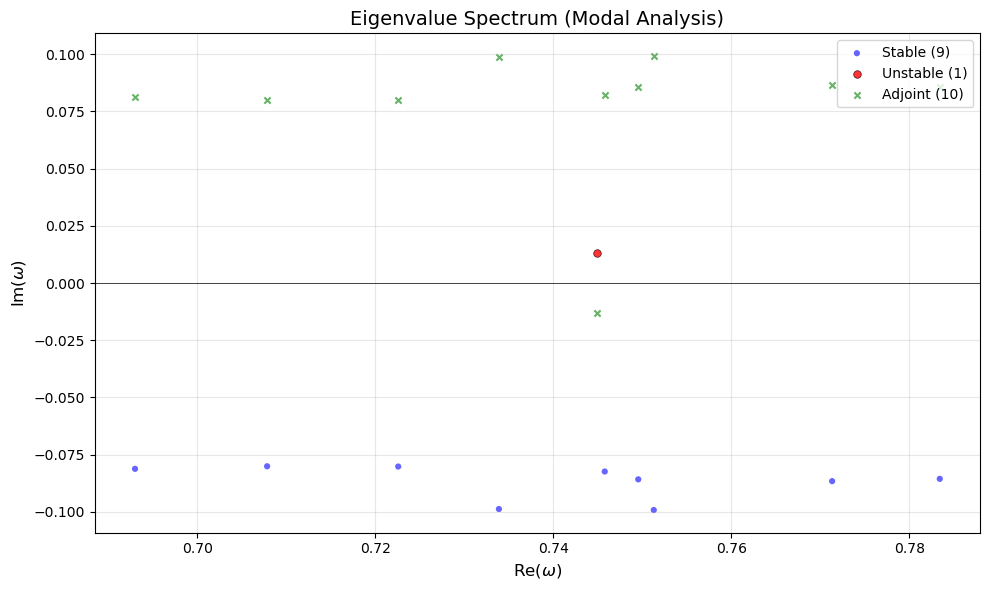

In [5]:
# Plotting the spectrum
ax = importSolution.plot_spectrum()

Text(0.5, 1.0, 'Leading adjoint mode shape')

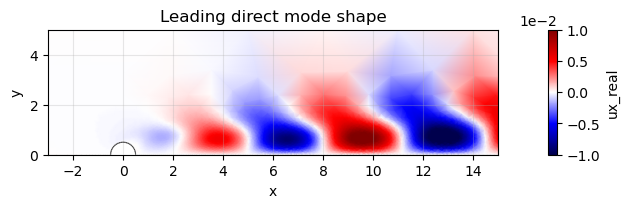

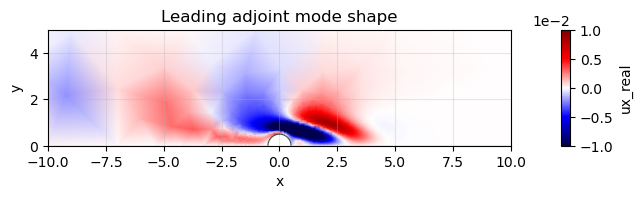

In [6]:
# Get the leading eigenvalue and eigenvector
leading_mode_direct    = importSolution.get_leading_mode()

# Similarly, we can get the leading adjoint mode
leading_mode_adjoint   = importSolution.get_leading_mode(adjoint = True)

# Plot the leading mode shape
ax = leading_mode_direct.plot(
    'ux', 
    xlim = (-3, 15), 
    ylim = (0, 5), 
    clim = (-1e-2, 1e-2)
)
ax.set_title("Leading direct mode shape")

# Plot the leading adjoint mode shape
ax = leading_mode_adjoint.plot(
    'ux', 
    xlim = (-10, 10), 
    ylim = (0, 5), 
    clim = (-1e-2, 1e-2)
)
ax.set_title("Leading adjoint mode shape")

---

## Post-treatment

Here is an example of simple post-treatment operation we can do using the FELiCS framework: computing the vorticity of the fluctuating velocity field.

🔬 FELiCS organizes the mixed state vector hierarchically:
```text
Mode
 └── Velocity field (u)
    └── Streamwise component (ux)
    └── Transverse component (uy)
 └── Pressure (p)
```

Let us now isolate the velocity components of the modes and compute the vorticity

Debug    | Field.py               | get_vorticity_field        (line 751 ) : Calculating gradient for component ux of the velocity field.
Debug    | Field.py               | get_vorticity_field        (line 751 ) : Calculating gradient for component uy of the velocity field.
Debug    | Field.py               | get_vorticity_field        (line 751 ) : Calculating gradient for component ux of the velocity field.
Debug    | Field.py               | get_vorticity_field        (line 751 ) : Calculating gradient for component uy of the velocity field.


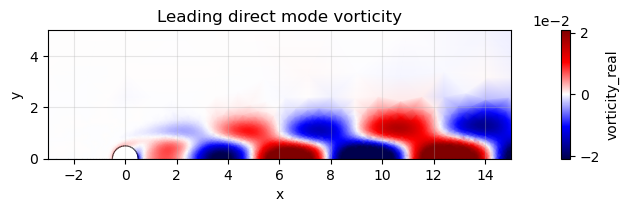

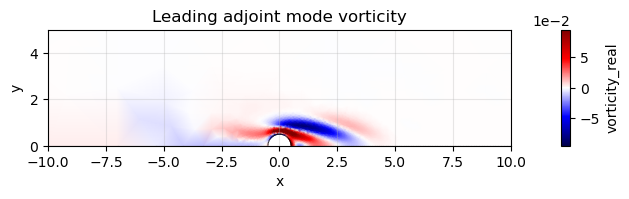

In [ ]:
# Extract the velocity part of the fluctuation state vector
u_direct            = leading_mode_direct.get_list_of_sub_fields()[0]
u_adjoint           = leading_mode_adjoint.get_list_of_sub_fields()[0]

# Compute the vorticity of modes
vorticity_direct    = u_direct.get_vorticity_field()
vorticity_adjoint   = u_adjoint.get_vorticity_field()

# Plot
# Plot the leading mode shape
ax = vorticity_direct.plot(
    xlim = (-3, 15), 
    ylim = (0, 5),
)
ax.set_title("Leading direct mode vorticity")

# Plot the leading adjoint mode shape
ax = vorticity_adjoint.plot(
    xlim = (-10, 10), 
    ylim = (0, 5),
)
ax.set_title("Leading adjoint mode vorticity")

# Save the vorticity to files
# Save to file using a FELiCS writer object
writer = Writer(exportDir = "results")
vorticity_direct.export_to_h5(writer, "vorticity_direct")
vorticity_adjoint.export_to_h5(writer, "vorticity_adjoint")